In [52]:
import pandas as pd

In [53]:
df = pd.read_csv('demand_forecasting_data.csv')

In [54]:
df.shape

(35000, 13)

In [55]:
df.head()

,Date,Product_ID,Base_Sales,Marketing_Campaign,Marketing_Effect,Seasonal_Trend,Seasonal_Effect,Price,Discount,Competitor_Price,Stock_Availability,Public_Holiday,Demand
0,2019-01-01,P002,65,Social Media,1.634270,Spring,1.0,73.496059,0.078198,64.173418,491,False,60570
1,2019-01-01,P004,94,Social Media,1.240566,Summer,1.2,74.271862,0.182151,69.571391,135,True,18143
2,2019-01-01,P003,125,Radio,1.087600,Summer,1.2,35.274616,0.102592,27.331268,180,False,37412
3,2019-01-01,P004,128,TV,1.831657,Winter,0.8,79.524248,0.196125,73.429502,227,False,40773
4,2019-01-01,P001,51,Radio,1.285161,Fall,1.1,96.237402,0.079253,88.243871,338,False,26917


In [56]:
df = df.drop_duplicates()

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                35000 non-null  object 
 1   Product_ID          35000 non-null  object 
 2   Base_Sales          35000 non-null  int64  
 3   Marketing_Campaign  27933 non-null  object 
 4   Marketing_Effect    35000 non-null  float64
 5   Seasonal_Trend      35000 non-null  object 
 6   Seasonal_Effect     35000 non-null  float64
 7   Price               35000 non-null  float64
 8   Discount            35000 non-null  float64
 9   Competitor_Price    35000 non-null  float64
 10  Stock_Availability  35000 non-null  int64  
 11  Public_Holiday      35000 non-null  bool   
 12  Demand              35000 non-null  int64  
dtypes: bool(1), float64(5), int64(3), object(4)
memory usage: 3.2+ MB


In [58]:
df.isnull().sum()

Date                     0
Product_ID               0
Base_Sales               0
Marketing_Campaign    7067
Marketing_Effect         0
Seasonal_Trend           0
Seasonal_Effect          0
Price                    0
Discount                 0
Competitor_Price         0
Stock_Availability       0
Public_Holiday           0
Demand                   0
dtype: int64

In [59]:
df['Marketing_Campaign'].unique()

array(['Social Media', 'Radio', 'TV', nan, 'Email'], dtype=object)

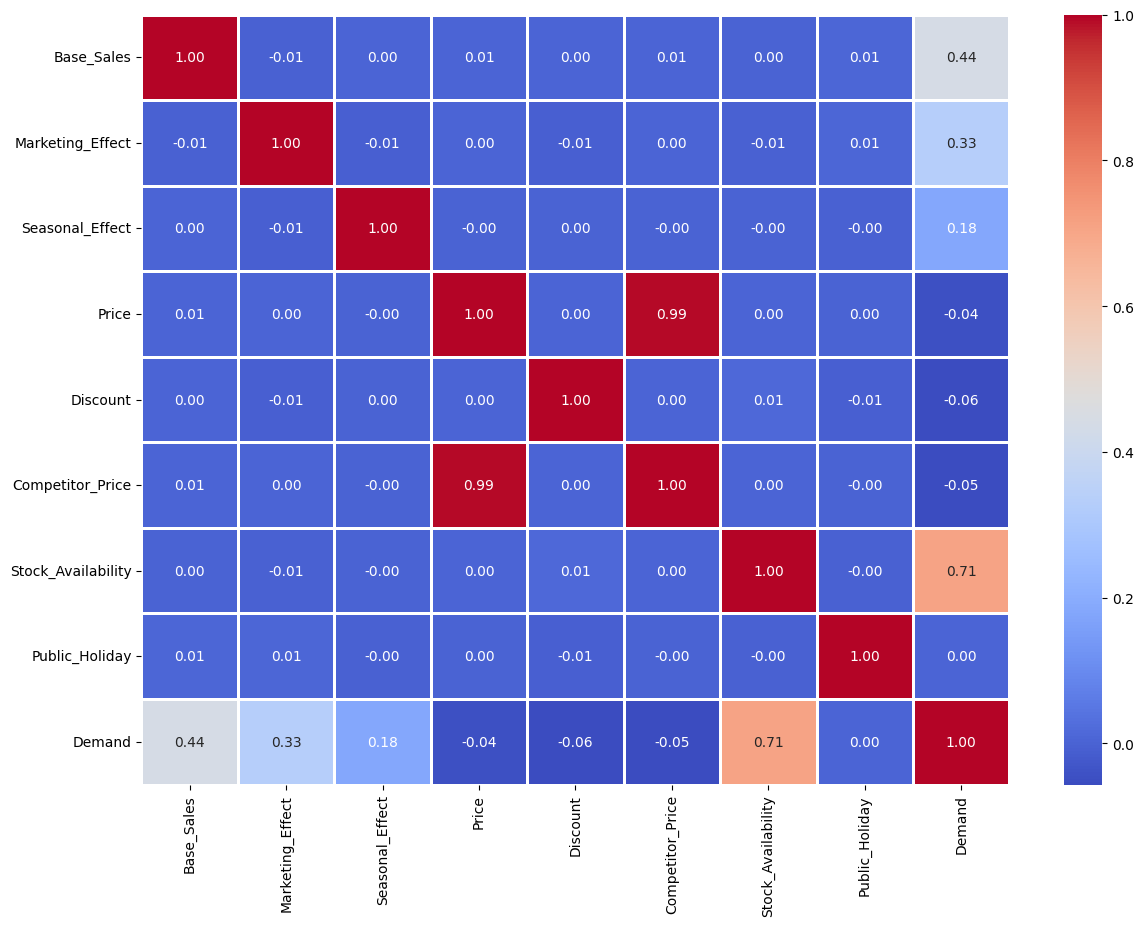

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', linewidths=1)
plt.show()

In [61]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["Quarter"] = df["Date"].dt.quarter

In [62]:
df.head()

,Date,Product_ID,Base_Sales,Marketing_Campaign,Marketing_Effect,Seasonal_Trend,Seasonal_Effect,Price,Discount,Competitor_Price,Stock_Availability,Public_Holiday,Demand,Year,Month,Day,DayOfWeek,Quarter
0,2019-01-01,P002,65,Social Media,1.634270,Spring,1.0,73.496059,0.078198,64.173418,491,False,60570,2019,1,1,1,1
1,2019-01-01,P004,94,Social Media,1.240566,Summer,1.2,74.271862,0.182151,69.571391,135,True,18143,2019,1,1,1,1
2,2019-01-01,P003,125,Radio,1.087600,Summer,1.2,35.274616,0.102592,27.331268,180,False,37412,2019,1,1,1,1
3,2019-01-01,P004,128,TV,1.831657,Winter,0.8,79.524248,0.196125,73.429502,227,False,40773,2019,1,1,1,1
4,2019-01-01,P001,51,Radio,1.285161,Fall,1.1,96.237402,0.079253,88.243871,338,False,26917,2019,1,1,1,1


In [63]:
df['Year'].unique()

array([2019, 2020, 2021], dtype=int32)

In [64]:
df = df.sort_values("Date").reset_index(drop=True)

In [65]:
df.head()

,Date,Product_ID,Base_Sales,Marketing_Campaign,Marketing_Effect,Seasonal_Trend,Seasonal_Effect,Price,Discount,Competitor_Price,Stock_Availability,Public_Holiday,Demand,Year,Month,Day,DayOfWeek,Quarter
0,2019-01-01,P002,65,Social Media,1.634270,Spring,1.0,73.496059,0.078198,64.173418,491,False,60570,2019,1,1,1,1
1,2019-01-01,P003,127,TV,1.845757,Summer,1.2,62.178761,0.095887,55.176390,265,True,83542,2019,1,1,1,1
2,2019-01-01,P004,199,NaN,1.000000,Fall,1.1,31.632994,0.186831,27.380065,159,False,35968,2019,1,1,1,1
3,2019-01-01,P003,108,Radio,1.524854,Winter,0.8,38.800570,0.072728,30.434871,216,False,37005,2019,1,1,1,1
4,2019-01-01,P001,72,Email,1.065224,Summer,1.2,74.986304,0.165148,71.283626,378,True,33607,2019,1,1,1,1


In [66]:
train = df[df["Date"] < "2021-05-01"]
test  = df[df["Date"] >= "2021-05-01"]

In [67]:
train.shape

(27193, 18)

In [68]:
test.shape

(7807, 18)

In [69]:
X_train = train.drop(['Date', 'Demand'], axis=1)
y_train = train['Demand']

X_test = test.drop(['Date', 'Demand'], axis=1)
y_test = test['Demand']

In [70]:
X_train.head()

,Product_ID,Base_Sales,Marketing_Campaign,Marketing_Effect,Seasonal_Trend,Seasonal_Effect,Price,Discount,Competitor_Price,Stock_Availability,Public_Holiday,Year,Month,Day,DayOfWeek,Quarter
0,P002,65,Social Media,1.634270,Spring,1.0,73.496059,0.078198,64.173418,491,False,2019,1,1,1,1
1,P003,127,TV,1.845757,Summer,1.2,62.178761,0.095887,55.176390,265,True,2019,1,1,1,1
2,P004,199,NaN,1.000000,Fall,1.1,31.632994,0.186831,27.380065,159,False,2019,1,1,1,1
3,P003,108,Radio,1.524854,Winter,0.8,38.800570,0.072728,30.434871,216,False,2019,1,1,1,1
4,P001,72,Email,1.065224,Summer,1.2,74.986304,0.165148,71.283626,378,True,2019,1,1,1,1


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                35000 non-null  datetime64[ns]
 1   Product_ID          35000 non-null  object        
 2   Base_Sales          35000 non-null  int64         
 3   Marketing_Campaign  27933 non-null  object        
 4   Marketing_Effect    35000 non-null  float64       
 5   Seasonal_Trend      35000 non-null  object        
 6   Seasonal_Effect     35000 non-null  float64       
 7   Price               35000 non-null  float64       
 8   Discount            35000 non-null  float64       
 9   Competitor_Price    35000 non-null  float64       
 10  Stock_Availability  35000 non-null  int64         
 11  Public_Holiday      35000 non-null  bool          
 12  Demand              35000 non-null  int64         
 13  Year                35000 non-null  int32     

In [72]:
df['Product_ID'].nunique()

5

In [73]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

num_col = ['Base_Sales',
       'Marketing_Effect', 'Seasonal_Effect', 'Price',
       'Discount', 'Competitor_Price', 'Stock_Availability',
        'Year', 'Month', 'Day', 'DayOfWeek', 'Quarter']

cat_col =['Product_ID',"Marketing_Campaign", 'Seasonal_Trend']

num_pipiline = Pipeline([
    ('ss', StandardScaler())
])

cat_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

In [74]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', num_pipiline, num_col),
    ('cat', cat_pipeline, cat_col)
])

In [75]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score


lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
y_pred_train = lr.predict(X_train)

print('train')
print(mean_squared_error(y_train, y_pred_train))
print(root_mean_squared_error(y_train, y_pred_train))
print(mean_absolute_error(y_train, y_pred_train))
print(r2_score(y_train, y_pred_train))

print('test')
print(mean_squared_error(y_test, y_pred))
print(root_mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

train
200131278.19542414
14146.776247450305
9957.73371013231
0.8591006147107807
test
210778834.6152726
14518.224223894347
10106.895741934479
0.855748359225013


In [77]:
from sklearn.ensemble import GradientBoostingRegressor



gb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor())
])
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)
y_pred_train = gb.predict(X_train)

print('train')
print(mean_squared_error(y_train, y_pred_train))
print(root_mean_squared_error(y_train, y_pred_train))
print(mean_absolute_error(y_train, y_pred_train))
print(r2_score(y_train, y_pred_train))

print('test')
print(mean_squared_error(y_test, y_pred))
print(root_mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

train
22946831.691334467
4790.285136746504
3177.7887310617552
0.9838446318396715
test
29776436.35485182
5456.778935860589
3446.37843326885
0.9796217689102447
